In [10]:
#Need to read the lines out
#For now don't omit the Ch0 replicas
#Need to read from both of the files and make sure the lrms are the same! Throw out the event if EITHER of the TFs replicate Ch0 exactly

#Really only need to calculate some number of y values for every strip. Can just do like 100?

#p0a p1a p2a is pol2 fit between 0-190 ADC ch 
#p0b p1b p2b p3b is pol3 fit between 190-500 ADC ch 
#p0c p1c p2c p3c is pol3 fit between 500-900 ADC ch 
#p0d p1d p2d p3d is pol3 fit between 900-1600 ADC ch 

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

nl = 7
nr = 6
nm = 6
ns = 32

tots = nl*nr*nm*ns

#Short.txt
with open('TF_Fit_Coefficients_Calibration_24November2025_Updated.txt', 'r') as f:
    lines = f.readlines()
    line_count = len(lines)
print(f"Total lines: {line_count}")
print(tots)
#5 commented lines in the .txt file

xvals = np.arange(0, 1600,10)
y_1 = np.zeros((nl*nr*nm*ns,len(xvals))) #Nlines different strips, calculate y_1, the transfer function output, at x locations
y_2 = np.zeros((nl*nr*nm*ns,len(xvals))) #Nlines different strips, calculate y_2, the transfer function output, at x locations
perc = np.zeros((nl*nr*nm*ns,len(xvals))) #Nlines different strips, calculate percent at number of x locations

coeffs_0000 = np.zeros(18)
coeffs = np.zeros(18)

coeffs_0000_2 = np.zeros(18)
coeffs_2 = np.zeros(18)

#Short.txt
with open('TF_Fit_Coefficients_Calibration_24November2025_Updated.txt', 'r') as f:
    next(f)
    next(f)
    next(f)
    next(f)
    next(f)
    first_line = f.readline()
    tarray = first_line.strip().split(',')
    
    p0_190 = Polynomial([float(tarray[4]),float(tarray[5]),float(tarray[6])])
    p190_500 = Polynomial([float(tarray[7]),float(tarray[8]),float(tarray[9]),float(tarray[10])])
    p500_900 = Polynomial([float(tarray[11]),float(tarray[12]),float(tarray[13]),float(tarray[14])])
    p900_1600 = Polynomial([float(tarray[15]),float(tarray[16]),float(tarray[17]),float(tarray[18])])

    for i in range(18):
        coeffs_0000[i] = float(tarray[i]) #Storing the coefficients 

#Short2.txt
with open('TF_Fit_Coefficients_Calibration_1227.txt', 'r') as f:
    next(f)
    next(f)
    next(f)
    next(f)
    next(f)
    first_line = f.readline()
    tarray = first_line.strip().split(',')
    
    p0_190_2 = Polynomial([float(tarray[4]),float(tarray[5]),float(tarray[6])])
    p190_500_2 = Polynomial([float(tarray[7]),float(tarray[8]),float(tarray[9]),float(tarray[10])])
    p500_900_2 = Polynomial([float(tarray[11]),float(tarray[12]),float(tarray[13]),float(tarray[14])])
    p900_1600_2 = Polynomial([float(tarray[15]),float(tarray[16]),float(tarray[17]),float(tarray[18])])

    for i in range(18):
        coeffs_0000_2[i] = float(tarray[i]) #Storing the coefficients 

#ADC to keV
def tf_fit(ADC): 
    if(ADC < 190 and ADC > 0):
        return p0_190(ADC)
    if(ADC > 190 and ADC < 500):
        return p190_500(ADC)
    if(ADC > 500 and ADC < 900):
        return p500_900(ADC)
    if(ADC > 900 and ADC < 1600):
        return p900_1600(ADC)

def tf_fit_2(ADC): 
    if(ADC < 190 and ADC > 0):
        return p0_190_2(ADC)
    if(ADC > 190 and ADC < 500):
        return p190_500_2(ADC)
    if(ADC > 500 and ADC < 900):
        return p500_900_2(ADC)
    if(ADC > 900 and ADC < 1600):
        return p900_1600_2(ADC)

Total lines: 8069
8064


In [2]:
name = "TF_Fit_Coefficients_Calibration_24November2025_Updated.txt"
pltfile = open(name, "r")

for i, x in enumerate(pltfile):
    tarray = x.strip().split(',')
    if i > 4: #i is the row!, x is the things in the row
        p0_190 = Polynomial([float(tarray[4]),float(tarray[5]),float(tarray[6])])
        p190_500 = Polynomial([float(tarray[7]),float(tarray[8]),float(tarray[9]),float(tarray[10])])
        p500_900 = Polynomial([float(tarray[11]),float(tarray[12]),float(tarray[13]),float(tarray[14])])
        p900_1600 = Polynomial([float(tarray[15]),float(tarray[16]),float(tarray[17]),float(tarray[18])])
        ind = 1152*int(tarray[0])+192*int(tarray[1])+32*int(tarray[2])+int(tarray[3]) #index of the strip of saved values
        for k in range(18):
            coeffs[k] = float(tarray[k]) #Storing the coefficients 
        if np.all(coeffs[4:] == coeffs_0000[4:]):
            continue #This makes you skip the next lines in the loop! So it does what I think it does
            #print(tarray[0] + tarray[1]+ tarray[2] + tarray[3])
            #print("All same!") #Hey it works!

        for j in range(len(xvals)):
            y_1[ind][j] = tf_fit(xvals[j])
            #print(y_1[i][j])
        #print(tarray[0] + tarray[1]+ tarray[2] + tarray[3])

name2 = "TF_Fit_Coefficients_Calibration_1227.txt"
pltfile2 = open(name2, "r")

for i, x in enumerate(pltfile2):
    tarray = x.strip().split(',')
    if i > 4: #i is the row!, x is the things in the row
        p0_190_2 = Polynomial([float(tarray[4]),float(tarray[5]),float(tarray[6])])
        p190_500_2 = Polynomial([float(tarray[7]),float(tarray[8]),float(tarray[9]),float(tarray[10])])
        p500_900_2 = Polynomial([float(tarray[11]),float(tarray[12]),float(tarray[13]),float(tarray[14])])
        p900_1600_2 = Polynomial([float(tarray[15]),float(tarray[16]),float(tarray[17]),float(tarray[18])])
        ind = 1152*int(tarray[0])+192*int(tarray[1])+32*int(tarray[2])+int(tarray[3]) #index of the strip of saved values
        for k in range(18):
            coeffs_2[k] = float(tarray[k]) #Storing the coefficients 
        if np.all(coeffs_2[4:] == coeffs_0000_2[4:]):
            continue #This makes you skip the next lines in the loop! So it does what I think it does
            #print(tarray[0] + tarray[1]+ tarray[2] + tarray[3])
            #print("All same!") #Hey it works!

        for j in range(len(xvals)):
            y_2[ind][j] = tf_fit_2(xvals[j])
            if(y_2[ind][j] is not None and y_1[ind][j] is not None and y_2[ind][j] != 0 and y_1[ind][j] != 0): perc[ind][j] = y_2[ind][j]/y_1[ind][j]
            #print(y_1[i][j])
        #print(tarray[0] + tarray[1]+ tarray[2] + tarray[3])

In [3]:
with open('TF_Fit_Coefficients_Calibration_24November2025_Updated.txt', 'r') as f:
    lines = f.readlines()
    line_count = len(lines)
print(f"Total lines: {line_count}")

with open('TF_Fit_Coefficients_Calibration_1227.txt', 'r') as f:
    lines = f.readlines()
    line_count = len(lines)
print(f"Total lines: {line_count}")

Total lines: 8069
Total lines: 8069


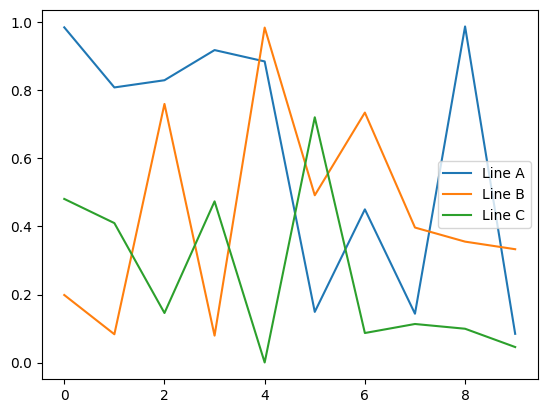

In [4]:
# Create sample 2D data: 3 rows (lines), 10 columns (points)
data = np.random.rand(3, 10)
labels = ['Line A', 'Line B', 'Line C']

for i, row in enumerate(data):
    plt.plot(row, label=labels[i])

plt.legend()
plt.show()

In [5]:
test = np.zeros((5,3))
test[2][2] = 1
test[1][2] = 5

print(test)
print(test[2][2])

[[0. 0. 0.]
 [0. 0. 5.]
 [0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]]
1.0


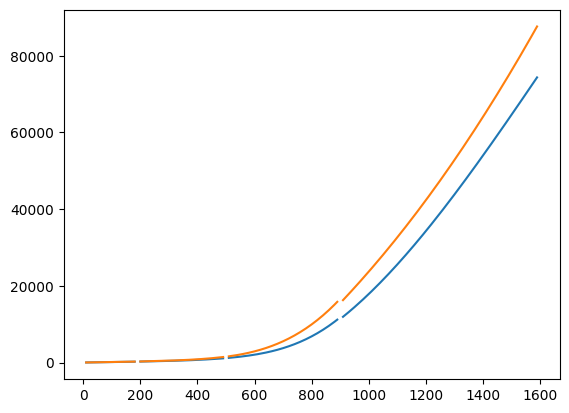

In [6]:
plt.plot(xvals,y_1[20])
plt.plot(xvals,y_2[20])

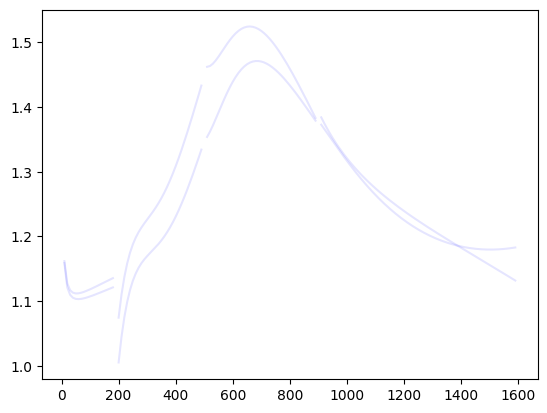

In [7]:
plt.plot(xvals,perc[8],color = 'blue',alpha = 0.1)
plt.plot(xvals,perc[9],color = 'blue',alpha = 0.1)

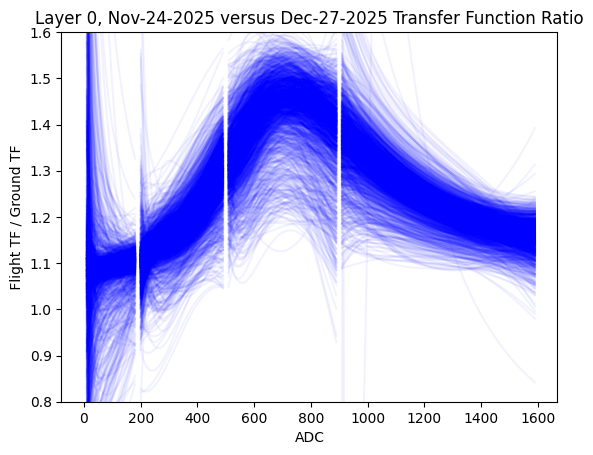

In [8]:
pltar = np.arange(6,2000)
plt.ylim(0.8, 1.6)
plt.title('Layer 0, Nov-24-2025 versus Dec-27-2025 Transfer Function Ratio')
plt.xlabel("ADC")
plt.ylabel(" Flight TF / Ground TF ")
for i in pltar:
    plt.plot(xvals,perc[i],color = 'blue',alpha = 0.05)

In [107]:
#My analysis is fine as is if I can show the pedestal is basically equal o-o;; 
#Would need to think a little harder if wanted to show differences!
#Would likely do ADC - ped_ground/flight, right?
#Seems like: L R M S Pedestal Sigma

#Alright so amazingly somehow, all of the pedestal txt file have different, sometimes wild, numbers of rows 
#What is the best way to deal with this?

import numpy as np
import matplotlib.pyplot as plt

pedDiff = np.zeros((tots,2)) #Theoretically correct number of lines, 32*6*6*7, lrms, ped1, ped2
#pedDiff = np.zeros((3,2))

Novname = "pedestal_24November2025.txt"
Decname = "ped_1227.txt"

with open(Novname, 'r') as f:
    lines = f.readlines()
    Nov_line_count = len(lines)
print(f"Total Nov lines: {Nov_line_count}")

with open(Decname, 'r') as f:
    lines = f.readlines()
    Dec_line_count = len(lines)
print(f"Total Dec lines: {Dec_line_count}")

Novped = np.zeros(Nov_line_count)
Decped = np.zeros(Dec_line_count)
#pedDiff = np.zeros(nl*nr*nm*ns) #Theoretically correct number of lines, 32*6*6*7
#Can have three rows, the "label" and you can check the label to see if correct, then ped1, and ped2

pedfileNov = open(Novname, "r")
pedfileDec = open(Decname, "r")

for i, x in enumerate(pedfileNov):
    tarray = x.strip().split(' ')
    #print(ind)
    ind = 1152*int(tarray[0])+192*int(tarray[1])+32*int(tarray[2])+int(tarray[3])
    pedDiff[ind][0] = float(tarray[4])

for i, x in enumerate(pedfileDec):
    tarray = x.strip().split(' ')
    ind = 1152*int(tarray[0])+192*int(tarray[1])+32*int(tarray[2])+int(tarray[3])
    pedDiff[ind][1] = float(tarray[4])
    #for i in range(len(tarray)):
    #    print(tarray[i])
    #Decped[i] = tarray[4]
    #pedDiff[i] = Decped[i] - Novped[i]



Total Nov lines: 8064
Total Dec lines: 11072


[   0    1    2 ... 8061 8062 8063]
[27]


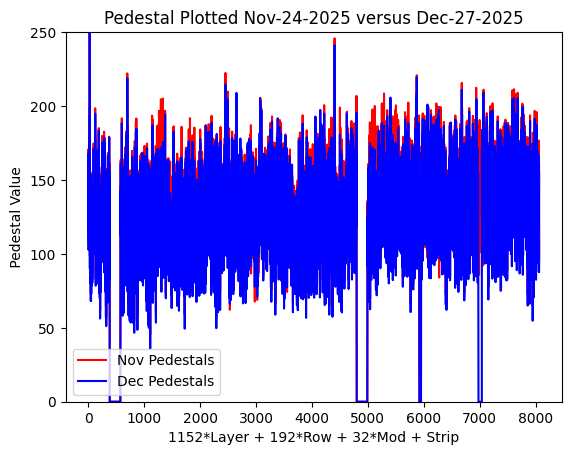

In [144]:
#print(pedDiff)
xped = np.arange(0, len(pedDiff[:,0]))
print(xped)

indices = [i for i, x in enumerate(pedDiff[:,0]) if x > 1000]
print(indices)

plt.plot(xped,pedDiff[:,0],label = 'Nov Pedestals',color='red')
plt.plot(xped,pedDiff[:,1],label = 'Dec Pedestals',color='blue')

plt.ylim(0, 250)
plt.title('Pedestal Plotted Nov-24-2025 versus Dec-27-2025')
plt.xlabel("1152*Layer + 192*Row + 32*Mod + Strip")
plt.ylabel(" Pedestal Value ")
plt.legend()
plt.show()

#Unclear what is happening with strip 27 here o-o;;

In [125]:
print(pedDiff[:,0])

[122.86 161.97 124.99 ... 140.59  95.54 161.15]


In [68]:
1152*6 + 192*5 + 32*5 + 31 #Seems good!
#Would be able to "unfurl" with layer = floor(index/1152) etc... etc...

8063

In [127]:
indices = [i for i, x in enumerate(pedDiff[:,0]) if x > 1000]
print(indices)

[27]


In [131]:
pedDiff[27,1]

1044.75

In [23]:
tf_fit(1599)

76482.72203

In [22]:
tf_fit(400)

755.8200000000002